## Definition of an AI Agent

An AI agent is an intelligent system that receives a high-level goal from a user and autonomously plans, decides, and executes a sequence of actions by using external tools, APIs, or knowledge sources — all while:

- Maintaining context  
- Reasoning over multiple steps  
- Adapting to new information  
- Optimizing for the intended outcome
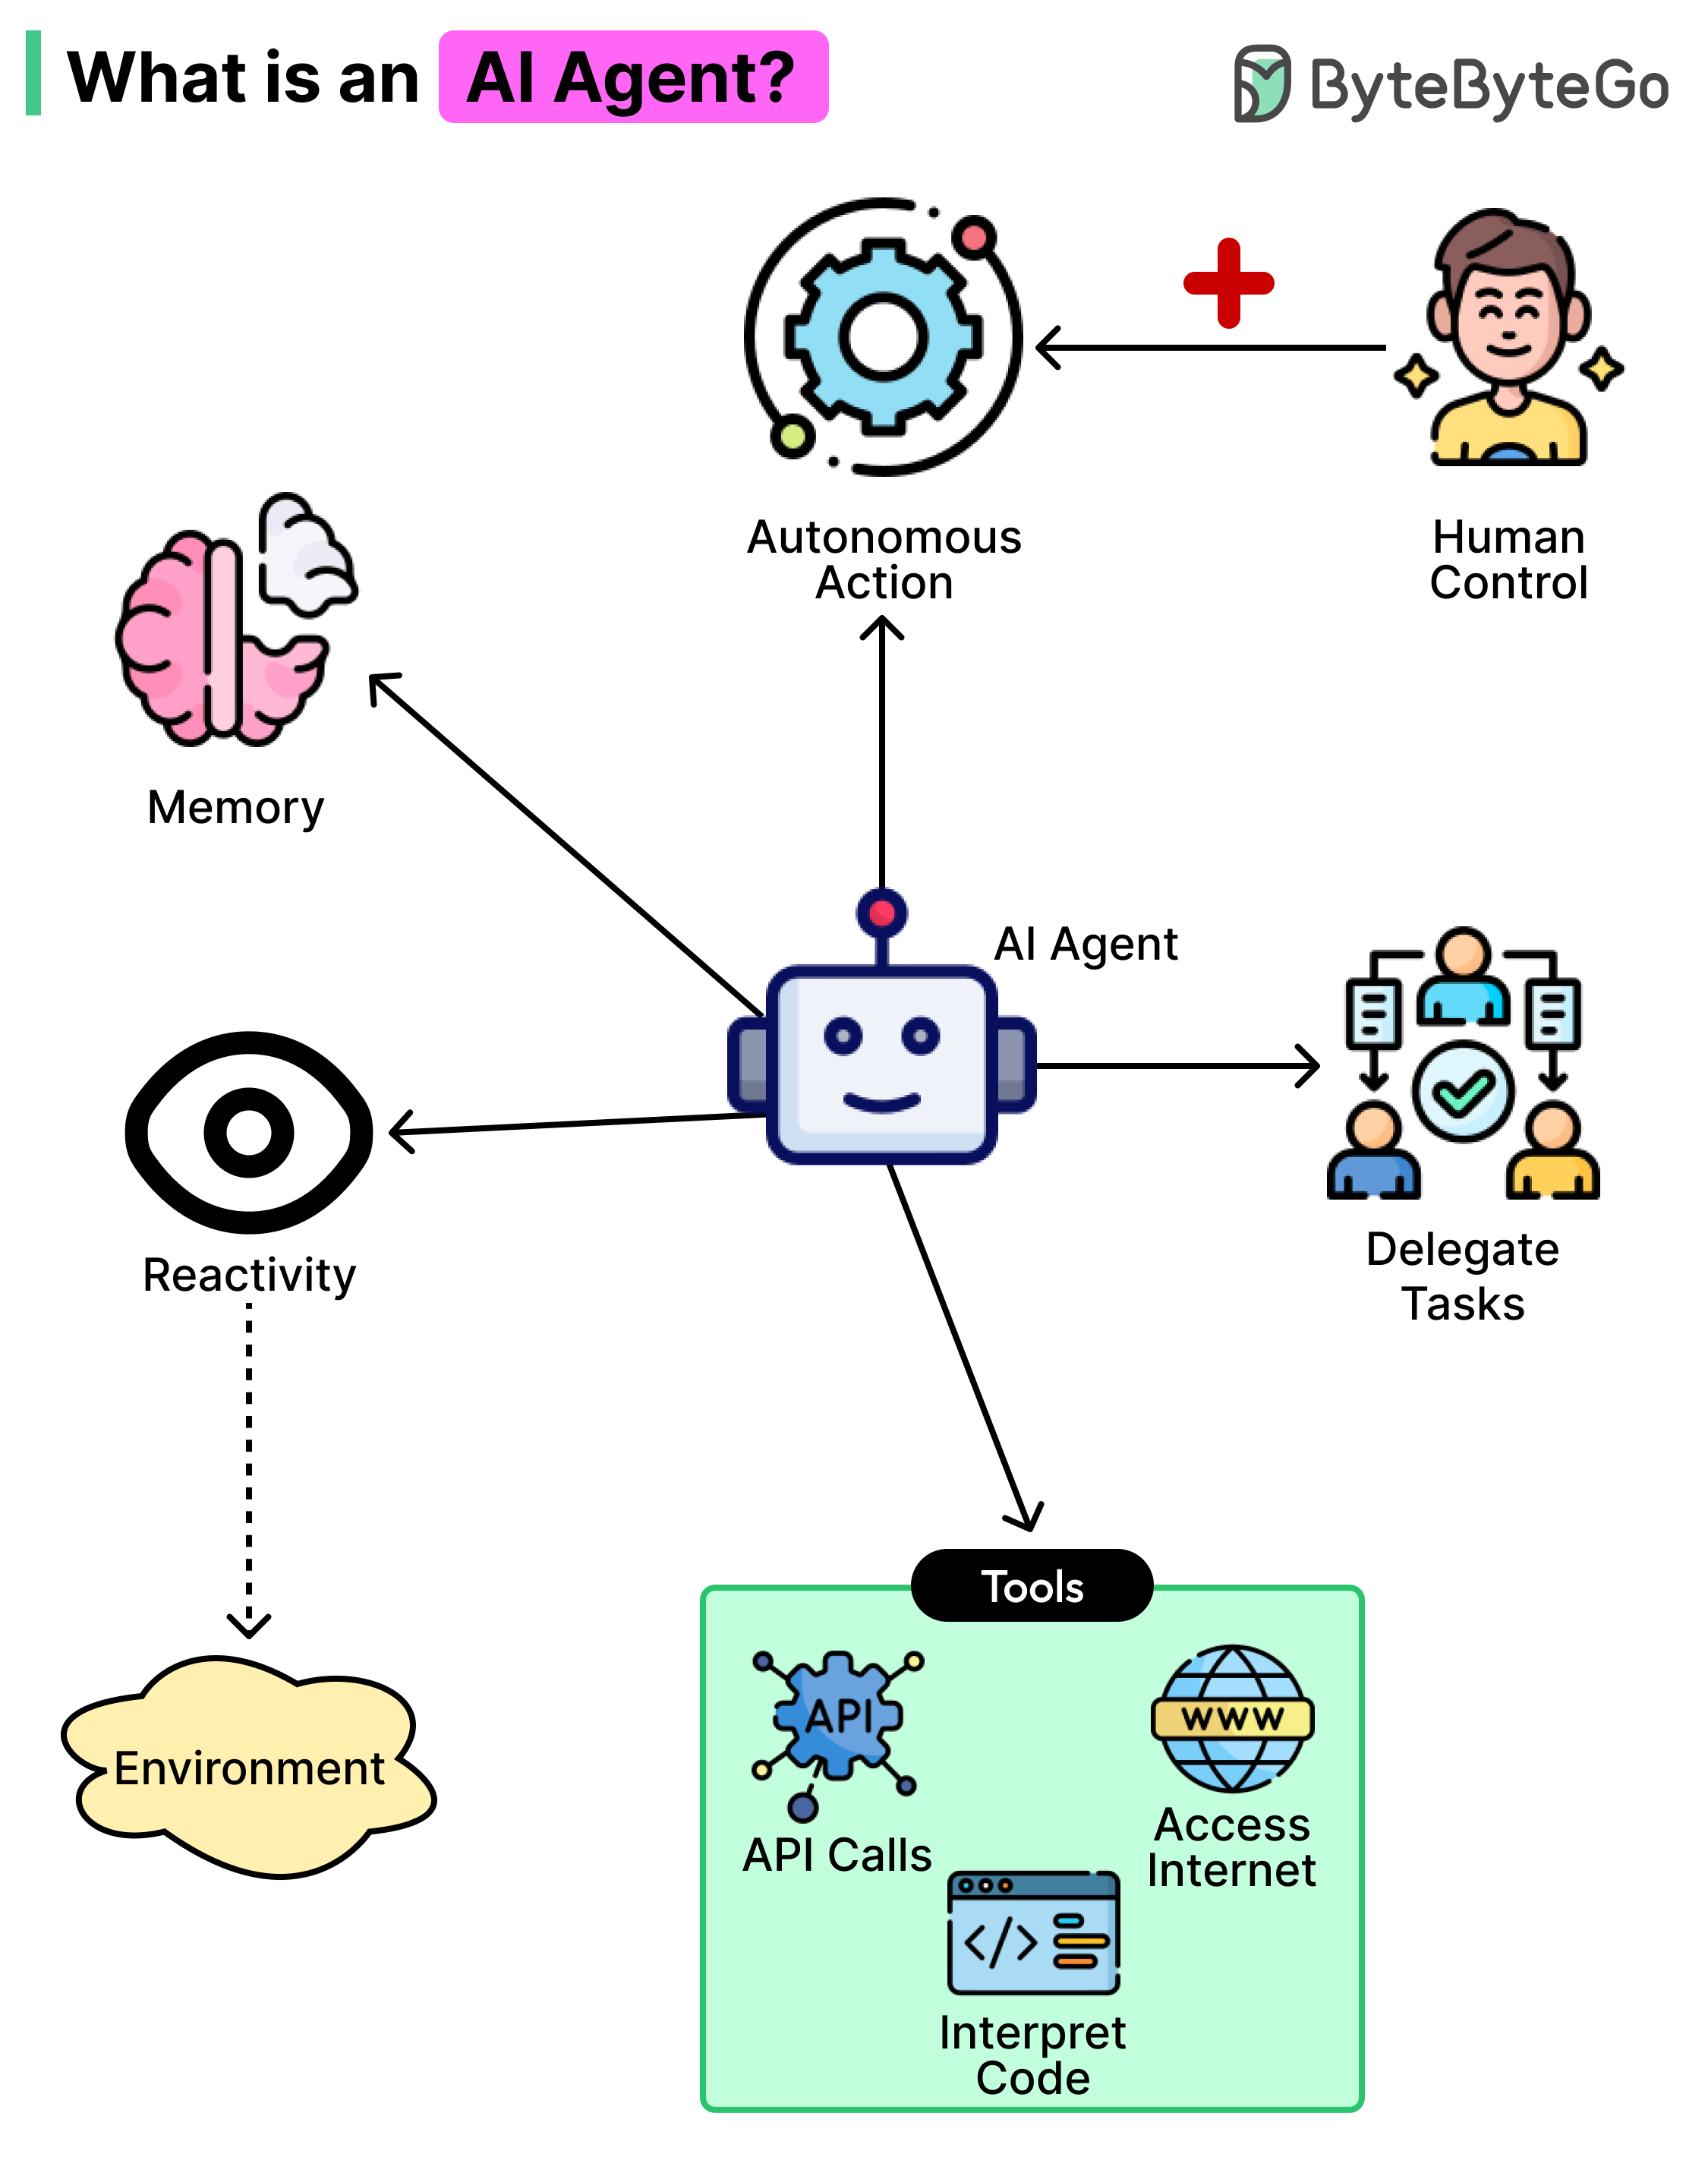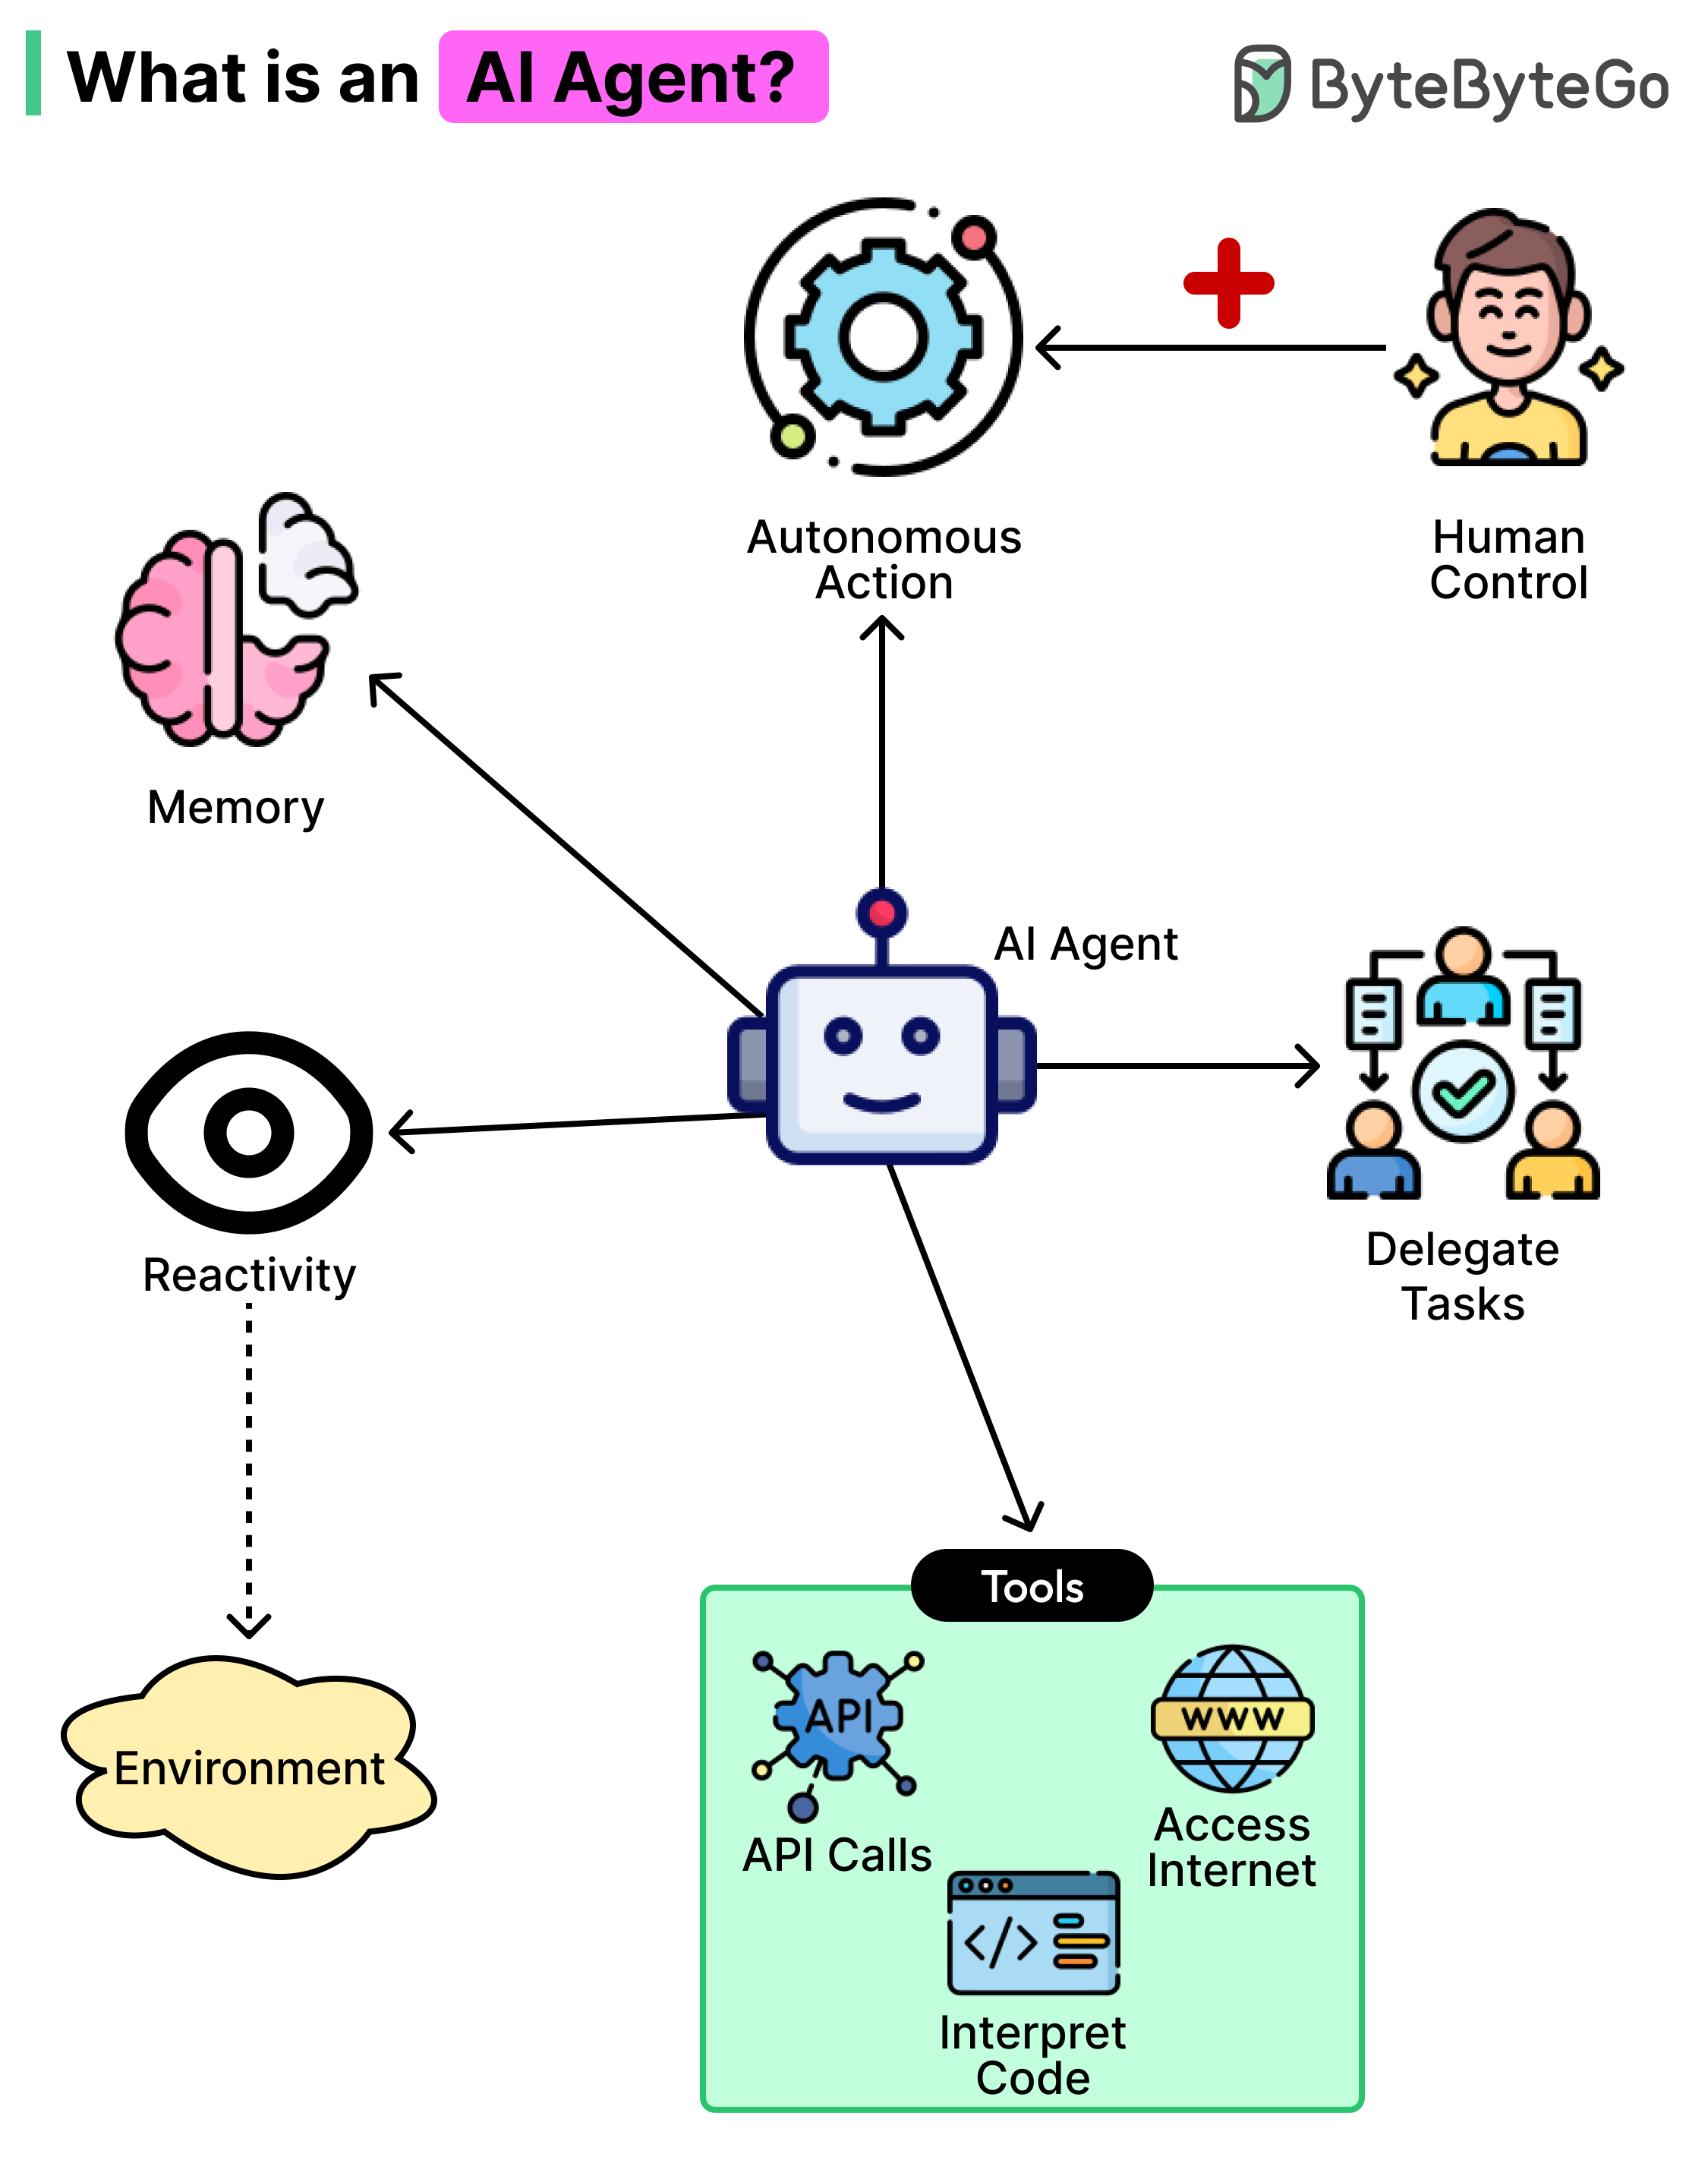
## AI Agent – Characteristics (In Short)

- **Autonomous** – Acts without constant human control  
- **Goal-Oriented** – Works toward achieving a defined objective  
- **Reasoning Ability** – Thinks and makes decisions  
- **Planning** – Breaks tasks into steps  
- **Tool Usage** – Can use external tools/APIs  
- **Memory** – Maintains context over time  
- **Adaptability** – Adjusts based on new information  
- **Multi-step Execution** – Handles complex workflows

In [15]:
!pip install langchainhub

  Using cached packaging-24.2-py3-none-any.whl.metadata (3.2 kB)
Using cached packaging-24.2-py3-none-any.whl (65 kB)
  Attempting uninstall: packaging
    Found existing installation: packaging 25.0
    Uninstalling packaging-25.0:
      Successfully uninstalled packaging-25.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain-huggingface 1.2.0 requires huggingface-hub<1.0.0,>=0.33.4, but you have huggingface-hub 1.3.5 which is incompatible.


In [2]:
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langchain_core.tools import tool
from langchain_community.tools import DuckDuckGoSearchRun
import requests
load_dotenv()

/mnt/d/Learning/Java/genAI/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [6]:
# tool
search_tool = DuckDuckGoSearchRun()
results = search_tool.invoke('Top news in India Today')
print(results)

2 hours ago · India Today was live. 35m. . #LIVE | Watch the top headlines at this ... #LIVE || Take a look at the top news headlines. 6 hours ago · 5.7K views. 23 ... 2 days ago · Top stories · Trump Tariffs Live Updates: "I Have The Best Legal Team," Says Lawyer Neal Katyal On Win Against Trump · Chaos, confusion and $200 billion dreams: ... 1 hour ago · India News · 85 Countries Rally Behind New Delhi Declaration As AI Impact Summit Wraps Up · 88 Nations Adopt New Delhi Declaration, Back India's "AI For All" ... Rating 4.0 (17,327) · Free · Android 23 hours ago · Watch Top TV Shows & Programs Stream the best of India Today, including News Today with Rajdeep Sardesai, Newstrack with Rahul Kanwal, To the Point, and more. 8 hours ago · India Today was live. 1h. ...


In [8]:
# LLm
llm = ChatOpenAI()
llm.invoke('Hi')

AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 8, 'total_tokens': 17, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DBmwBVjmSZ9IE5OSZGANjQQEk8Qqw', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019c81ac-89ba-7a61-b502-fbea9c6546c7-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 8, 'output_tokens': 9, 'total_tokens': 17, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [42]:
# 🔹 Create agent
agent = create_agent(
    model=llm,
    tools=[search_tool],
    system_prompt="""
    You are a helpful assistant that can search the web when needed. """
)

In [43]:
for chunk in agent.stream(
    {"messages": [{"role": "user", "content": "3 Ways to reach Bangalore?"}]},
    stream_mode="updates",
):
    for step, data in chunk.items():
        message = data["messages"][-1]

        print(f"\n🔹 Step: {step}")

        # Tool call
        if hasattr(message, "tool_calls") and message.tool_calls:
            for call in message.tool_calls:
                print("Action:", call["name"])
                print("Action Input:", call["args"])

        # Tool output
        elif message.type == "tool":
            print("Observation:", message.content[:200])

        # Final answer
        else:
            print("Final Answer:", message.content)


🔹 Step: model
Action: duckduckgo_search
Action Input: {'query': '3 ways to reach Bangalore'}

🔹 Step: tools
Observation: Mantralayam from Bangalore travel guide with 10 best bus & train options. Get timings, fares & tips for your pilgrimage. Book your journey now! Bangalore Metro is fast becoming the lifeline of commute

🔹 Step: model
Final Answer: Here are 3 ways to reach Bangalore:

1. By Bus: Book a bus ticket for a comfortable journey to Bangalore from various cities and towns.
   
2. By Train: Take a train to Bangalore with multiple options available from different locations across India.

3. By Flight: Travel to Bangalore by air via the Kempegowda International Airport, which connects the city to major domestic and international destinations.


## ReAct in LangChain 1.x

- ✅ Can show ReAct format (via prompt).
- ❌ Cannot expose real internal chain-of-thought.

Visible:
- Tool Call
- Tool Output
- Final Answer

---

## Is LangChain Still Used for Agents?

- ✅ Yes, LangChain is still used.
- ⚡ Good for simple tool-calling agents and RAG.
- ❌ Not ideal for complex, multi-step agents.

---

## What About LangGraph?

- 🔥 Recommended for advanced agents.
- Supports planner → tool → loop workflows.
- Better control and production-ready design.
- 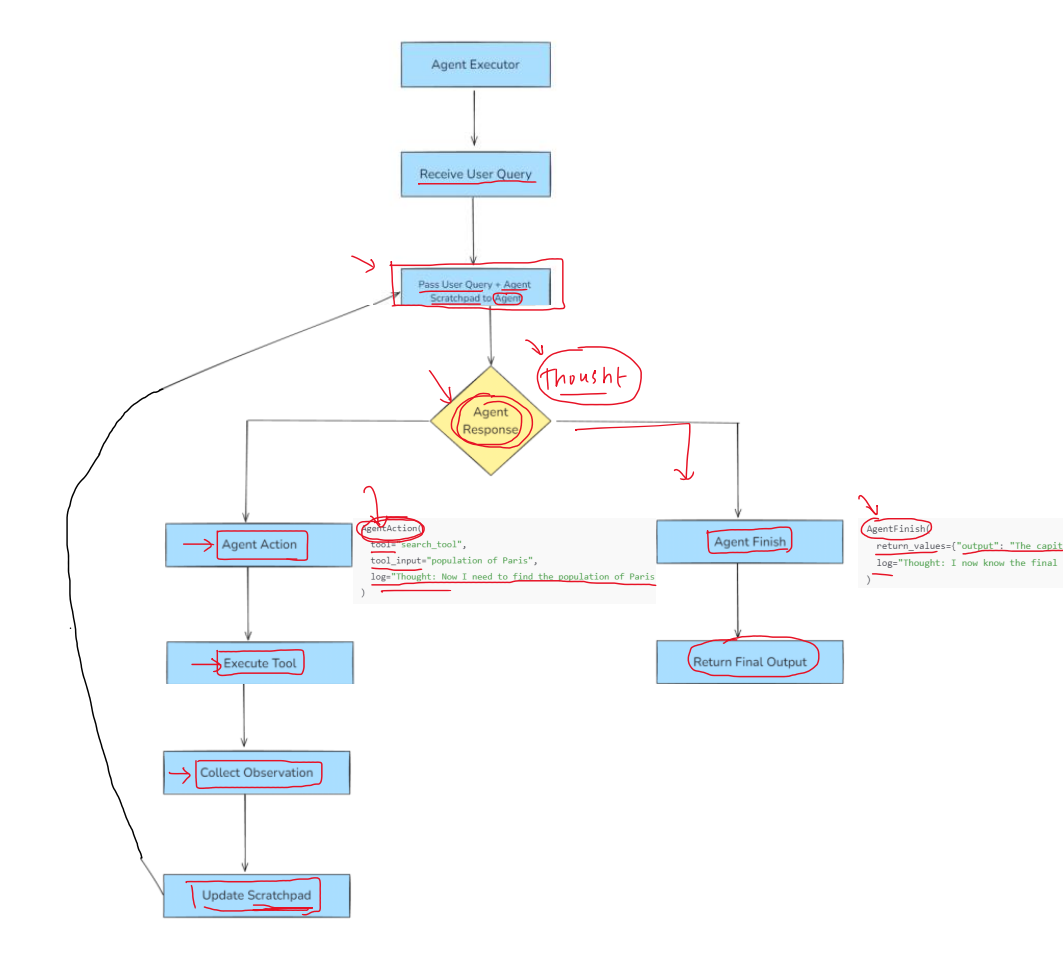